<a href="https://colab.research.google.com/github/gilIolgenblum/ProteinCrowding/blob/main/tutorials/01b_binary_plots_showcase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Binary Model: Plotting Showcase

This notebook demonstrates the plotting functionality available in the `BinaryPlotter` for analyzing and visualizing the thermodynamics of the binary crowding model (protein + solvent + single cosolute).

In [1]:
import os
import sys

# Check if we are running in Google Colab
if 'google.colab' in str(get_ipython()):
    # Clone the repository to get the data files
    !git clone https://github.com/gilIolgenblum/ProteinCrowding.git
    # Change the working directory to the repository root
    os.chdir('/content/ProteinCrowding')
    # Install the package dependencies
    !pip install -e .

    # TELL PYTHON WHERE THE SOURCE FOLDER IS
    sys.path.append('/content/ProteinCrowding/src')

Cloning into 'ProteinCrowding'...
remote: Enumerating objects: 444, done.
remote: Counting objects: 100% (444/444), done.
remote: Compressing objects: 100% (260/260), done.
remote: Total 444 (delta 228), reused 384 (delta 179), pack-reused 0 (from 0)
Receiving objects: 100% (444/444), 14.21 MiB | 22.02 MiB/s, done.
Resolving deltas: 100% (228/228), done.
Obtaining file:///content/ProteinCrowding
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for fh_crowding (pyproject.toml) ... done
  Created wheel for fh_crowding: filename=fh_crowding-0.1.0-0.editable-py3-none-any.whl size=3165 sha256=8eea2a325b95fafb9fd7b109c9e773f16eece2936d1a095bd6956d7896c6ae35
  Stored in directory: /tmp/pip-ephem-wheel-cache-h8_q1ats/wheels/8e/87/c6/59b0297bcdbde056eefb789604b557fd569845c8580cefb7a2
Successfully built fh_crowding


In [2]:
import fh_crowding
import matplotlib.pyplot as plt
import numpy as np
from fh_crowding.plotting import BinaryPlotter

# Define the protein (e.g., SASA = 419.0 A^2)
protein = fh_crowding.Protein(SASA=419.0)

# Define the cosolute
cosolute = fh_crowding.Cosolute(
    nu=2.479,      # Excluded volume parameter
    chi=0.610,     # Flory-Huggins interaction parameter
    chiTS=-3.650   # Entropic component of chi
)
# Initialize the binary model
model = fh_crowding.BinaryCrowdingModel(
    protein=protein,
    cosolute=cosolute,
    eps=-0.05,        # Soft interaction energy
    epsTS=0.01,       # Entropic component of soft interaction
    phiC_max=0.15,    # Maximum volume fraction to simulate
    dphiC=0.005,      # Step size for the grid
    T=298.15          # Temperature in Kelvin
)

# Solve the thermodynamic equilibrium equations across the concentration grid
model.solve_equil()

# Initialize the plotter
plotter = BinaryPlotter(model)
print("Model initialized and solved. Plotter ready.")

Model initialized and solved. Plotter ready.


## Comprehensive Results Plot (`plot_results()`)

The `plot_results()` method generates a 3x3 grid of subplots covering all critical thermodynamic properties.

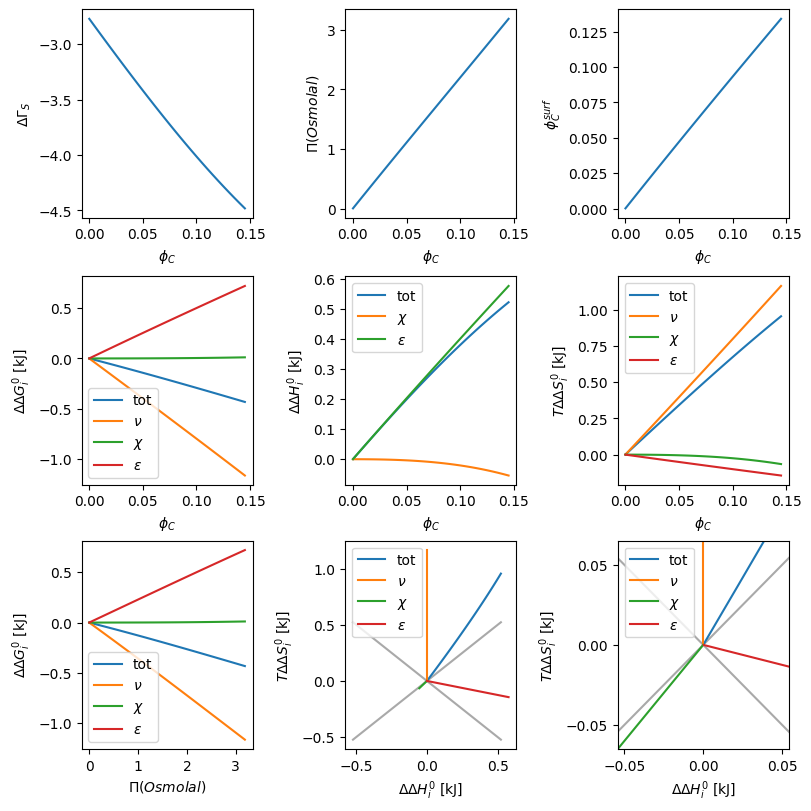

In [3]:
fig = plotter.plot_results()
plt.show()

## Individual Plots

The `BinaryPlotter` also provides individual plotting methods. By default, the x-axis is volume fraction ($\phi$), but you can change it using `concentration_type='molal'` or `concentration_type='molar'`.

### Preferential Interaction Parameter ($\Delta\Gamma_S$)

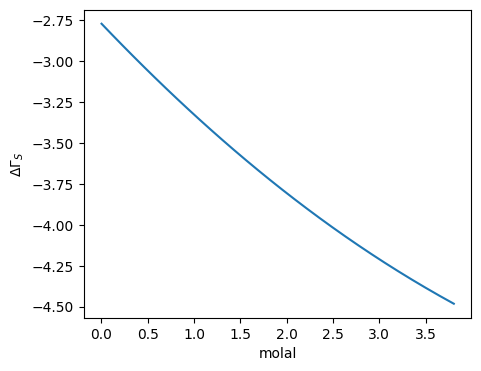

In [4]:
fig = plotter.plot_gamma(concentration_type='molal')
plt.show()

### Folding Free Energy ($\Delta\Delta G$)

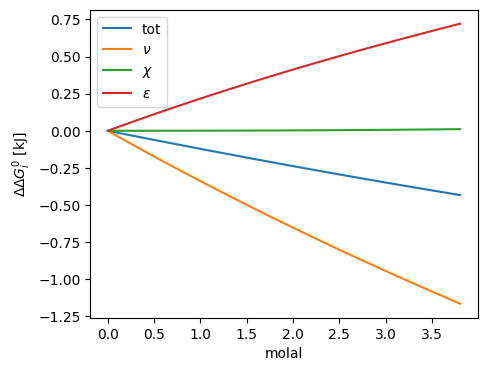

In [5]:
fig = plotter.plot_ddG(concentration_type='molal')
plt.show()

### Folding Enthalpy ($\Delta\Delta H$)

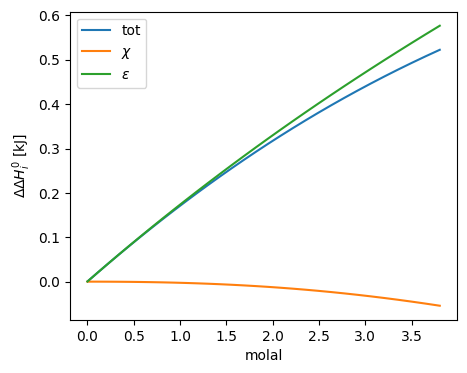

In [6]:
fig = plotter.plot_ddH(concentration_type='molal')
plt.show()

### Folding Entropy ($T\Delta\Delta S$)

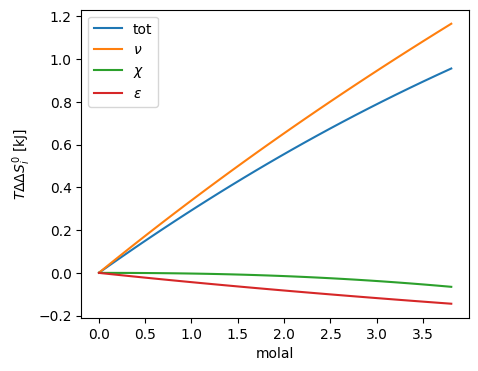

In [7]:
fig = plotter.plot_TddS(concentration_type='molal')
plt.show()

### Chemical Potential ($\mu$)

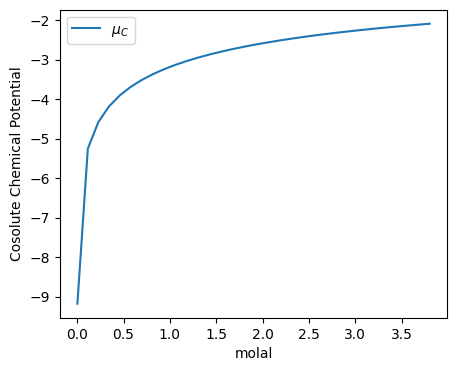

In [8]:
fig = plotter.plot_mu(concentration_type='molal')
plt.show()

### Osmotic Pressure ($\Pi$)

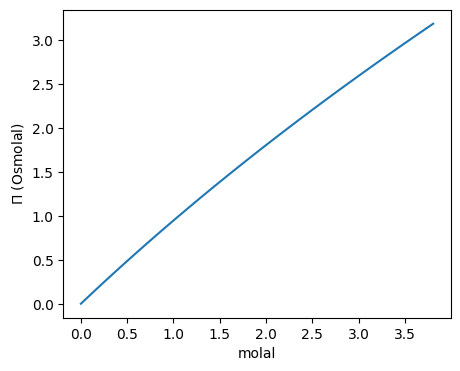

In [9]:
fig = plotter.plot_osm(concentration_type='molal')
plt.show()

### Enthalpy-Entropy Compensation (Standalone)

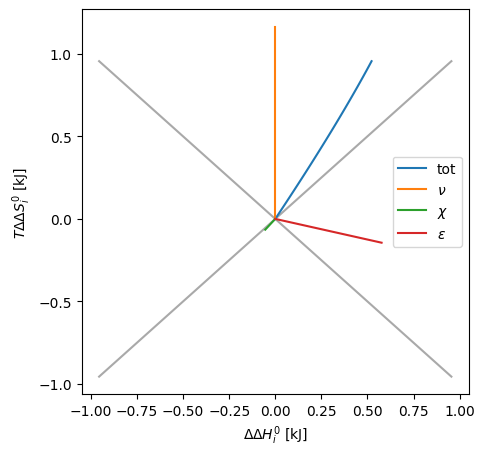

In [10]:
fig = plotter.plot_EEC()
plt.show()